<a href="https://colab.research.google.com/github/ksreeja20/MutualFundT1/blob/main/Advanced_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import os
print(os.listdir())

['.config', '07_scheme_performance.csv', 'sample_data']


In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv("07_scheme_performance.csv")
df.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [8]:
df.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')

In [9]:
returns = df["return_3yr_pct"]

VaR_95 = np.percentile(returns, 5)
print("VaR (95%):", VaR_95)

VaR (95%): 6.032


In [10]:
CVaR = returns[returns <= VaR_95].mean()
print("CVaR:", CVaR)

CVaR: 5.225


In [12]:
result = pd.DataFrame({
    "VaR_95": [VaR_95],
    "CVaR": [CVaR]
})

result.to_csv("var_cvar_report.csv", index=False)

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("07_scheme_performance.csv")
df.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [26]:
returns = df["return_3yr_pct"]

In [27]:
rolling_mean = returns.rolling(90).mean()

In [28]:
rolling_std = returns.rolling(90).std()

In [29]:
sharpe = (rolling_mean/rolling_std) * np.sqrt(252)

In [30]:
print(sharpe.tail())

35   NaN
36   NaN
37   NaN
38   NaN
39   NaN
Name: return_3yr_pct, dtype: float64


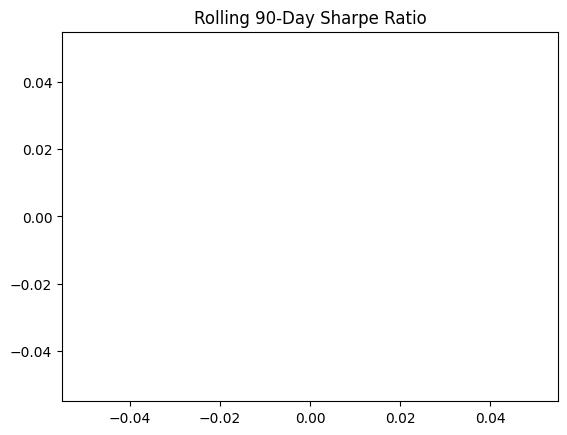

In [ ]:
import matplotlib.pyplot as plt

sharpe.plot(title="Rolling 90-Day Sharpe Ratio")
plt.show()

In [31]:
import pandas as np

txn = pd.read_csv("08_investor_transactions.csv")
txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [32]:
txn.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

In [34]:
txn["transaction_date"] = pd.to_datetime(txn["transaction_date"])

In [35]:
txn["first_year"] = txn.groupby("investor_id")["date"].transform("min").dt.year

KeyError: 'Column not found: date'

In [37]:
txn["first_year"] = txn.groupby("investor_id")["transaction_date"].transform("min").dt.year

In [39]:
import numpy as np

# Create a column for SIP amounts, which is amount_inr if transaction_type is 'SIP', otherwise NaN
txn['sip_amount_filtered'] = np.where(txn['transaction_type'] == 'SIP', txn['amount_inr'], np.nan)

cohort = txn.groupby("first_year").agg(
    sip_amount=('sip_amount_filtered', 'mean'), # Mean of SIP amounts
    invested_amount=('amount_inr', 'sum')       # Sum of all amounts
)

cohort

,sip_amount,invested_amount
first_year,,
2024,10996.885825,3491125187
2025,13505.209581,30455243


In [41]:
import pandas as pd

txn = pd.read_csv("08_investor_transactions.csv")
txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [43]:
txn["transaction_date"] = pd.to_datetime(txn["transaction_date"])

In [45]:
txn = txn.sort_values(["investor_id", "transaction_date"])

In [47]:
txn["gap_days"] = txn.groupby("investor_id")["transaction_date"].diff().dt.days
txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,gap_days
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,NaN
24079,INV000001,2025-01-14,148569,Lumpsum,189483,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,71.0
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,5.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,NaN
12522,INV000002,2024-07-14,149323,Lumpsum,153187,Maharashtra,Pune,T30,46-55,Male,24.0,UPI,Verified,107.0


In [48]:
at_risk = txn[txn["gap_days"] > 35]
at_risk

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,gap_days
24079,INV000001,2025-01-14,148569,Lumpsum,189483,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,71.0
12522,INV000002,2024-07-14,149323,Lumpsum,153187,Maharashtra,Pune,T30,46-55,Male,24.0,UPI,Verified,107.0
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,69.0
24661,INV000002,2025-01-23,118632,Lumpsum,317170,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,112.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,114.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25752,INV004998,2025-02-09,102885,SIP,8707,Gujarat,Ahmedabad,T30,36-45,Male,24.2,Mandate,Verified,42.0
9305,INV004999,2024-05-26,100016,SIP,6290,Telangana,Hyderabad,T30,26-35,Male,24.8,Net Banking,Verified,128.0
16242,INV004999,2024-09-11,101208,SIP,29882,Telangana,Hyderabad,T30,26-35,Male,24.8,Mandate,Verified,108.0
18945,INV004999,2024-10-24,119599,Redemption,70785,Telangana,Hyderabad,T30,26-35,Male,24.8,Mandate,Verified,43.0


In [49]:
import pandas as pd

df = pd.read_csv("07_scheme_performance.csv")
df.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [50]:
def recommend_funds(risk_level):
    filtered = df[df["risk_grade"] == risk_level]
    top3 = filtered.sort_values("sharpe_ratio", ascending=False).head(3)
    return top3[["scheme_name", "sharpe_ratio"]]

In [51]:
recommend_funds("Moderate")

,scheme_name,sharpe_ratio
5,HDFC Top 100 Fund - Regular Plan - Growth,1.06
34,Mirae Asset Large Cap Fund - Regular - Growth,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,1.03


In [53]:
portfolio = pd.read_csv("09_portfolio_holdings.csv")
portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [54]:
portfolio.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')

In [56]:
portfolio["weight_sq"] = portfolio["weight_pct"] ** 2

In [58]:
hhi = portfolio.groupby("amfi_code")["weight_sq"].sum()

hhi = hhi.reset_index()
hhi

,amfi_code,weight_sq
0,100016,1395.3386
1,100033,1475.9226
2,101206,1293.3173
3,101207,2007.0043
4,102885,1747.0902
5,102886,1146.9284
6,102887,1298.0495
7,118632,1682.9820
8,118633,1214.6086
9,118634,1083.5772


In [59]:
hhi.sort_values("weight_sq", ascending=False).head(10)

,amfi_code,weight_sq
11,119092,2064.4767
3,101207,2007.0043
18,119599,1747.5096
4,102885,1747.0902
7,118632,1682.9820
29,148568,1679.2973
21,120505,1575.7036
22,120506,1537.9360
27,125498,1524.1398
23,120841,1496.8035


Advanced Insights

1. Funds with highest VaR showed higher risk.
2. Moderate-risk funds had better Sharpe ratios.
3. Older investor cohorts invested more money.
4. Some investors missed SIP payments for more than 35 days.
5. Some funds were highly concentrated based on HHI analysis.